<div style="text-align: justify;">

# Time-Series Simulation and DER Modeling

## Objectives

This book's whole premise is that a smart-meter reading is worth more than
its own number: aggregated, modeled, and combined with what a meter alone
can't see (network topology, everyone else's demand at the same moment),
it becomes a real business decision. Chapter 1 built the network side of
that combination, an OpenDSS model of a real LV feeder, and ended on a
warning: one solved snapshot is not a verdict on a feeder's health. This
notebook is where the meter-signal side of the book's own premise finally
meets that network, real smart-meter readings driving a real feeder,
across a real week, to answer a real business question: how much rooftop
solar can this specific feeder actually take before someone has to act on
it.

Everything below runs on one feeder throughout, the same real 31-customer
AusNet network Chapter 1 introduced, real demand and real rooftop solar,
not a fresh toy network per concept. By the end you will be able to:

- Turn real smart-meter readings into `LoadShape`s and drive a full week
  of `Set Mode=daily` simulation with them.
- Model PV properly: an irradiance/temperature-driven `PVSystem`, not a
  flat kVA rating.
- Find a real voltage violation on this feeder, then fix it with
  Volt-Watt, Volt-VAr, and `Storage`, the same scenario each time, not
  three unrelated demos, and check whether either control raises the
  feeder's hosting capacity outright rather than patching one point.
- Check the *other* constraint too, transformer thermal loading against
  its 500 kVA rating, not just voltage, and see what changes when "worst
  case" means a specific real day versus a season's own representative
  profile.

`Circuit` picked up three new pieces for this chapter: `circuit.pvsystems`
and `circuit.storage_units` (iterators, the same pattern as
`circuit.loads`), and `circuit.solve_daily(steps, stepsize)` (steps through
a time-series solve, one call per half hour instead of one call per
network).

</div>

<div style="text-align: justify;">

## Getting the data

This notebook needs Team-Nando's real AusNet LV network and smart-meter
data, the same 31-customer feeder Chapter 1 introduced. It isn't checked
into the repository (it's someone else's licensed data, vendored locally
instead), so fetch it once:

```bash
uv run python scripts/fetch_part4_ausnet_data.py
```

That downloads `LVcircuit-*.txt` (the network model) and two `.npy` files,
342 real, anonymized customers' active power and normalized PV generation,
both at 30-minute resolution for a full year, into
`resources/cvar_flexibility/data/timeseries-lv/`.

</div>

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd

from ark.dss.circuit import Circuit

DATA_DIR = Path("../../resources/cvar_flexibility/data/timeseries-lv")

<div style="text-align: justify;">

## 1. The feeder this chapter studies

Every section below runs on this same network: the real 31-customer AusNet
feeder, one distribution transformer, 24 line segments, 31 single-phase
service cables, the same one Chapter 1's `01-opendss-lv-modeling-code.ipynb`
introduced and read circuit properties from. No toy network, no stand-in,
so a result from Section 4 and a result from Section 8 describe the same
physical feeder, not two unrelated ones. `Circuit.load` compiles it
straight from Team-Nando's own `.dss` files.

</div>

In [ ]:
def build_ausnet_network() -> Circuit:
    circuit = Circuit.load(DATA_DIR / "LVcircuit-master.txt", solve=False)
    circuit.command("Set VoltageBases = [22.0, 0.400]")
    circuit.command("calcvoltagebases")
    return circuit


circuit = build_ausnet_network()
circuit.solve()
circuit.summary()

{'converged': True,
 'n_buses': 61,
 'n_lines': 59,
 'n_loads': 31,
 'n_transformers': 1,
 'total_p_loss_kw': 0.6107992120127365,
 'total_q_loss_kvar': 0.15519491021295995}

<div style="text-align: justify;">

## 2. Real customers, real diversity

Before driving this feeder with real data, it's worth seeing what that
data actually looks like: not one representative household, but hundreds
of real, different ones.

</div>

In [ ]:
load_data = np.load(DATA_DIR / "Residential load data 30-min resolution.npy")
pv_data = np.load(DATA_DIR / "Residential PV data 30-min resolution.npy")

print(f"load_data: {load_data.shape} (customers, days, half-hours)")
print(f"pv_data:   {pv_data.shape} (days, half-hours), one normalised profile per day")

load_data: (342, 365, 48) (customers, days, half-hours)
pv_data:   (365, 48) (days, half-hours), one normalised profile per day


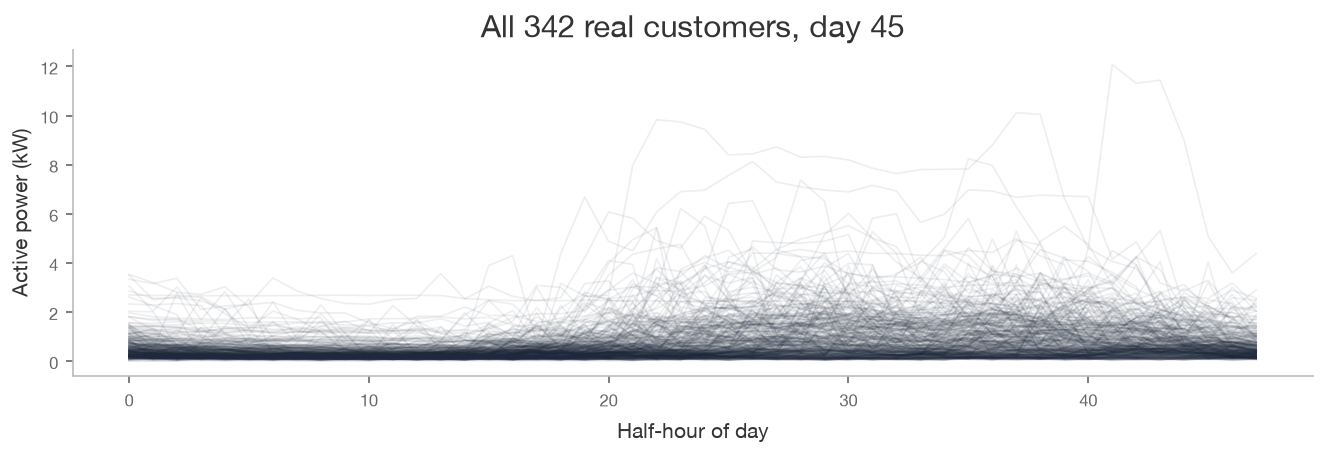

In [ ]:
import matplotlib.pyplot as plt

from ark.plot.matplot_theme import configure_matplotlib_style
from ark.plot.tokens import PRIMARY

configure_matplotlib_style()

selected_day = 45
fig, ax = plt.subplots(figsize=(9, 3.2))
for customer_profile in load_data[:, selected_day, :]:
    ax.plot(customer_profile, color=PRIMARY, alpha=0.08, linewidth=0.8)
ax.set_xlabel("Half-hour of day")
ax.set_ylabel("Active power (kW)")
ax.set_title(f"All 342 real customers, day {selected_day}")
plt.show()

<div style="text-align: justify;">

342 households, one day, and no two profiles agree: some barely draw
half a kilowatt all day, others spike past 5kW in the evening. Averaging
this away into "the" residential load shape would erase exactly the
variability a real feeder has to survive.

</div>

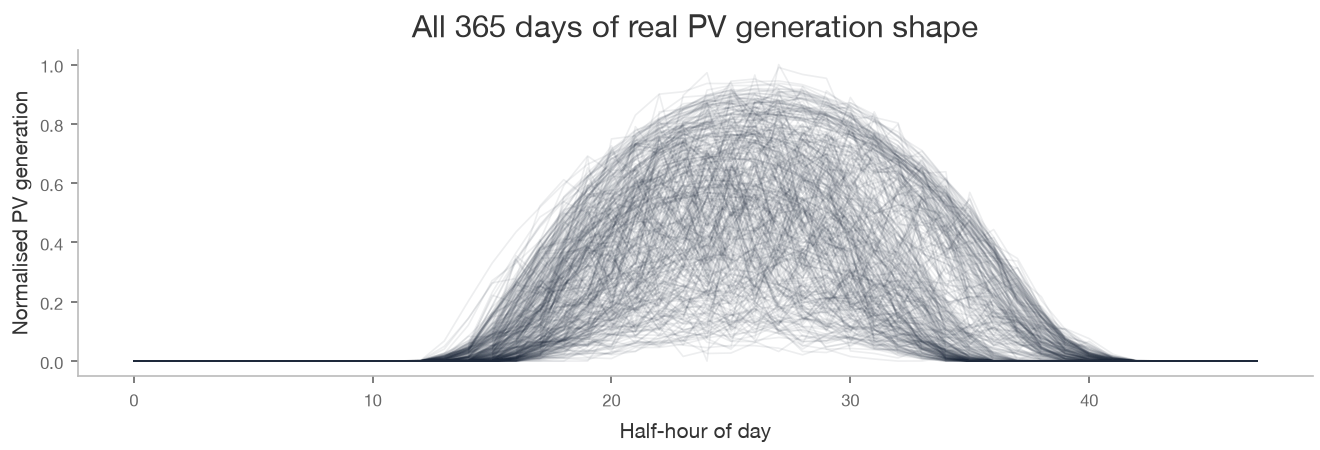

In [ ]:
fig, ax = plt.subplots(figsize=(9, 3.2))
for daily_pv_profile in pv_data:
    ax.plot(daily_pv_profile, color=PRIMARY, alpha=0.08, linewidth=0.8)
ax.set_xlabel("Half-hour of day")
ax.set_ylabel("Normalised PV generation")
ax.set_title("All 365 days of real PV generation shape")
plt.show()

<div style="text-align: justify;">

PV varies day to day the same way: cloudy days barely clear a third of
a clear day's peak. `run_penetration` later in this notebook deliberately
picks the single sunniest of these 365 days, the worst case for a
hosting-capacity study.

</div>

<div style="text-align: justify;">

## 3. From readings to LoadShapes

A meter only ever reports active power; reactive power (`qmult`) isn't
metered, so it's derived from an assumed power factor, the same
0.95-0.99 range Team-Nando's own tutorials use. `useactual=1` tells
OpenDSS the `pmult`/`qmult` arrays are already in kW/kvar, not multipliers
on the load's own rated capacity. Every one of the feeder's 31 loads gets
its own real customer profile, sampled from the 342 available (more real
customers exist than houses on this specific feeder).

</div>

In [ ]:
rng = np.random.default_rng(42)
loads = list(circuit.loads)
customer_indices = rng.choice(load_data.shape[0], size=len(loads), replace=False)

day_idx = 45
for load, customer_idx in zip(loads, customer_indices, strict=True):
    p = load_data[customer_idx, day_idx, :]
    pf = rng.uniform(0.95, 0.99, len(p))
    q = np.sqrt(np.maximum((p / pf) ** 2 - p**2, 0))
    circuit.command(
        f"New LoadShape.profile_{load.name} npts=48 minterval=30 useactual=1 pmult={p.tolist()} qmult={q.tolist()}"
    )
    circuit.command(f"edit load.{load.name} daily=profile_{load.name}")

print(f"All {len(loads)} houses now follow a real customer's day-{day_idx} reading")

All 31 houses now follow a real customer's day-45 reading


<div style="text-align: justify;">

### Checking the simulation is using what you think it's using

Attaching a `LoadShape` is one command; trusting it silently is a habit
worth breaking. Team-Nando's own tutorial cross-checks three independent
views of the same house's power at every half hour: the real data array
this notebook started from, what a live solve actually reports back for
that load, and what the `LoadShape` object itself has stored internally.
If any two of these disagree, something upstream is wrong, a stale
`Circuit` handle, a shape attached to the wrong load, data edited after
the shape was built, and it's much cheaper to catch that here than to
notice it three sections later in a chart that looks slightly off.

</div>

In [ ]:
check_load = loads[0]
actual = load_data[customer_indices[0], day_idx, :]

monitored = []
for _step in circuit.solve_daily(steps=48):
    p_kw = circuit.element_powers("loads").query("name == @check_load.name")["p_kw"].iloc[0]
    monitored.append(p_kw)

circuit.dss.LoadShape.Name(f"profile_{check_load.name}")
loadshape_pmult = list(circuit.dss.LoadShape.PMult())

verification = pd.DataFrame(
    {"half_hour": range(48), "actual": actual, "monitored": monitored, "loadshape": loadshape_pmult}
)
actual_vs_monitored = (verification["monitored"] - verification["actual"]).abs().max()
actual_vs_loadshape = (verification["loadshape"] - verification["actual"]).abs().max()
print(f"Largest gap, real data vs. what OpenDSS solved:        {actual_vs_monitored:.6f} kW")
print(f"Largest gap, real data vs. the LoadShape's own pmult:   {actual_vs_loadshape:.6f} kW")

Largest gap, real data vs. what OpenDSS solved:        0.000006 kW
Largest gap, real data vs. the LoadShape's own pmult:   0.000000 kW


<div style="text-align: justify;">

A gap at solver-tolerance scale (well under a watt) confirms the three
views agree: the real reading, the live circuit, and the stored
`LoadShape` are all describing the same house.

</div>

<div style="text-align: justify;">

## 4. A real week of simulation

`circuit.solve_daily(steps, stepsize)` steps through a `Set Mode=daily`
solve, but a single call only ever covers one day's worth of LoadShape
data. A real time-series study covers more than one day, so the loop
below rebuilds every LoadShape's `pmult`/`qmult` at the start of each new
day (`edit LoadShape...`, reusing the same shape rather than creating a
new one) and calls `solve_daily` seven times, the same `start_day`/
`total_days=7` window Team-Nando's own tutorial uses.

</div>

In [ ]:
start_day, total_days = 21, 7

week_rows = []
for day_offset in range(total_days):
    current_day = start_day + day_offset
    for load, customer_idx in zip(loads, customer_indices, strict=True):
        p = load_data[customer_idx, current_day, :]
        pf = rng.uniform(0.95, 0.99, len(p))
        q = np.sqrt(np.maximum((p / pf) ** 2 - p**2, 0))
        circuit.command(f"edit LoadShape.profile_{load.name} pmult={p.tolist()} qmult={q.tolist()}")

    for step in circuit.solve_daily(steps=48):
        # Exclude the source bus: it's held at its own fixed pu setpoint by
        # construction, not by anything the network does, so it reads as a
        # real voltage in bus_voltages() but says nothing about customer
        # voltage. See Circuit.source_bus's own docstring.
        voltages = circuit.bus_voltages().query("bus != @circuit.source_bus")
        transformer_power = circuit.element_powers("transformers")
        week_rows.append(
            {
                "day": day_offset,
                "step": step,
                "vmax_pu": voltages["vmag_pu"].max(),
                "vmin_pu": voltages["vmag_pu"].min(),
                "p1_kw": transformer_power.query("phase == 1")["p_kw"].iloc[0],
                "p2_kw": transformer_power.query("phase == 2")["p_kw"].iloc[0],
                "p3_kw": transformer_power.query("phase == 3")["p_kw"].iloc[0],
            }
        )

week_df = pd.DataFrame(week_rows)
week_df["half_hour"] = week_df["day"] * 48 + week_df["step"]
print(f"Converged: {circuit.converged}")
print(f"{len(week_df)} half-hour solves across {total_days} days")

Converged: True
336 half-hour solves across 7 days


In [ ]:
from lets_plot import LetsPlot, aes, geom_line, ggplot, ggsize, labs, scale_color_manual

from ark.plot.theme import modern_theme
from ark.plot.tokens import BRAND_PALETTE

LetsPlot.setup_html()

power_long = week_df.melt(
    id_vars=["half_hour"], value_vars=["p1_kw", "p2_kw", "p3_kw"], var_name="phase", value_name="kw"
)
(
    ggplot(power_long, aes(x="half_hour", y="kw", color="phase"))
    + geom_line(size=0.8)
    + scale_color_manual(values=BRAND_PALETTE[:3])
    + labs(x="Half-hour (7 days)", y="Transformer power (kW)", title="Transformer loading over a real week")
    + modern_theme()
    + ggsize(650, 320)
)

<div style="text-align: justify;">

Three phases, one real week: demand rises and falls with the daily
cycle, and no two days look quite the same, exactly the kind of pattern a
single snapshot could never show.

</div>

In [ ]:
from lets_plot import geom_hline

envelope_long = week_df.melt(
    id_vars=["half_hour"], value_vars=["vmax_pu", "vmin_pu"], var_name="bound", value_name="vmag_pu"
)
(
    ggplot(envelope_long, aes(x="half_hour", y="vmag_pu", color="bound"))
    + geom_line(size=0.8)
    + geom_hline(yintercept=1.10, linetype="dashed", color=BRAND_PALETTE[3], size=0.7)
    + geom_hline(yintercept=0.94, linetype="dashed", color=BRAND_PALETTE[3], size=0.7)
    + scale_color_manual(values=BRAND_PALETTE[:2])
    + labs(x="Half-hour (7 days)", y="Voltage (pu)", title="Feeder-wide voltage envelope over a real week")
    + modern_theme()
    + ggsize(650, 320)
)

<div style="text-align: justify;">

Comfortably inside the 0.94-1.10 pu band all week, no PV yet attached.
Section 6 revisits this exact feeder with rooftop solar added, and this
time the envelope doesn't stay so comfortable.

</div>

<div style="text-align: justify;">

## 5. Modeling PV properly

A `PVSystem` can run on a flat rating, constant output regardless of the
time of day. A more realistic model drives it from an irradiance profile
and a temperature profile instead, a `LoadShape` for sunlight and a
`Tshape` for panel temperature. Attaching one to a real house on this same
feeder, rather than a separate toy network, keeps the demonstration
grounded in the network this chapter actually cares about.

</div>

In [ ]:
pv_house = loads[0]

# Illustrative daily irradiance (fraction of 1kW/m^2) and panel temperature
# (degrees C), not real weather data: real AusNet data has normalised PV
# *generation* profiles (used directly in Section 6's hosting-capacity
# study), not separate irradiance/temperature series.
irradiance = [0, 0, 0, 0, 0, 0, 0.1, 0.2, 0.3, 0.5, 0.8, 0.9, 1.0, 1.0, 0.99, 0.9, 0.7, 0.4, 0.1, 0, 0, 0, 0, 0]
temperature = [15, 15, 15, 15, 15, 15, 16, 18, 20, 23, 26, 29, 31, 32, 31, 28, 24, 20, 17, 16, 15, 15, 15, 15]


def pv_export_by_hour(circuit: Circuit) -> list[float]:
    circuit.command(f"New LoadShape.irradiance_demo npts=24 minterval=60 mult={irradiance}")
    circuit.command(f"New Tshape.temp_demo npts=24 minterval=60 temp={temperature}")
    circuit.command("edit PVSystem.pv_demo daily=irradiance_demo Tdaily=temp_demo")
    return [-circuit.element_powers("pvsystems")["p_kw"].iloc[0] for _ in circuit.solve_daily(steps=24, stepsize="1h")]


default_cutin = build_ausnet_network()
default_cutin.command(
    f"new PVSystem.pv_demo bus1={pv_house.bus1} phases=1 kva=5 pmpp=5 pf=1 kV=(0.4 3 sqrt /) model=1 irradiance=1"
)
pv_export_default = pv_export_by_hour(default_cutin)
print("PV export by hour, OpenDSS's default %cutin/%cutout:", [round(p, 2) for p in pv_export_default])

PV export by hour, OpenDSS's default %cutin/%cutout: [np.float64(-0.0), np.float64(-0.0), np.float64(-0.0), np.float64(-0.0), np.float64(-0.0), np.float64(-0.0), np.float64(-0.0), np.float64(1.0), np.float64(1.5), np.float64(2.5), np.float64(4.0), np.float64(4.5), np.float64(5.0), np.float64(5.0), np.float64(4.95), np.float64(4.5), np.float64(3.5), np.float64(2.0), np.float64(-0.0), np.float64(-0.0), np.float64(-0.0), np.float64(-0.0), np.float64(-0.0), np.float64(-0.0)]


<div style="text-align: justify;">

::: {.ark-mistake}

**A 20% default nearly zeroed out the morning and evening.** OpenDSS's
`PVSystem` defaults `%cutin`/`%cutout` to 20%, the inverter output
threshold below which it won't turn on or stays off. At 10% irradiance
(hour 6 above), a real inverter still produces something, 0.1 x 5kW =
0.5kW, but a 20%-cutin model reports flat `0.0`, and it's easy to miss
unless every hour gets checked individually: hours 12-16, the middle of the
day, look identical either way. Team-Nando's own tutorials always override
this to `%cutin=0.05 %cutout=0.05`.

:::

</div>

In [ ]:
fixed_cutin = build_ausnet_network()
fixed_cutin.command(
    f"new PVSystem.pv_demo bus1={pv_house.bus1} phases=1 kva=5 pmpp=5 pf=1 kV=(0.4 3 sqrt /) model=1 "
    "irradiance=1 %cutin=0.05 %cutout=0.05"
)
pv_export_fixed = pv_export_by_hour(fixed_cutin)
print("PV export by hour, %cutin/%cutout=5%:      ", [round(p, 2) for p in pv_export_fixed])

PV export by hour, %cutin/%cutout=5%:       [np.float64(-0.0), np.float64(-0.0), np.float64(-0.0), np.float64(-0.0), np.float64(-0.0), np.float64(-0.0), np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.5), np.float64(4.0), np.float64(4.5), np.float64(5.0), np.float64(5.0), np.float64(4.95), np.float64(4.5), np.float64(3.5), np.float64(2.0), np.float64(0.5), np.float64(-0.0), np.float64(-0.0), np.float64(-0.0), np.float64(-0.0), np.float64(-0.0)]


In [ ]:
hours = pd.DataFrame(
    {
        "hour": list(range(24)) * 2,
        "kw": pv_export_default + pv_export_fixed,
        "cutin": ["20% (default)"] * 24 + ["5% (Team-Nando's own setting)"] * 24,
    }
)
(
    ggplot(hours, aes(x="hour", y="kw", color="cutin"))
    + geom_line(size=1)
    + scale_color_manual(values=BRAND_PALETTE[:2])
    + labs(x="Hour of day", y="PV export (kW)", title="The default cutin threshold silently drops real output")
    + modern_theme()
    + ggsize(650, 320)
)

<div style="text-align: justify;">

Rebuilding the same PV system with the lower threshold recovers exactly
the two hours the default silently dropped, visible directly against the
default in the chart above.

</div>

<div style="text-align: justify;">

## 6. The hosting-capacity crisis

This is the real business question a DSO (distribution system operator)
faces every time a new rooftop solar application arrives: does connecting
one more customer's PV system push this specific feeder past its
statutory voltage limit? Say yes too often and customers wait months for
a grid upgrade that may not have been necessary; say yes too rarely and a
real feeder starts violating compliance. A hosting-capacity study is how
that question gets a real, feeder-specific answer instead of a guess.

Every piece above comes together to run it: real load data becomes
LoadShapes on this same 31-customer feeder, a chosen share of customers
get real PV profiles, and the network solves across a full day, half hour
by half hour, at increasing PV penetration.

A feeder can fail this test two different ways, not one. Chapter 1
introduced all three real constraints an LV network operates under:
thermal, voltage, and phase balance. `run_penetration` below checks the
first two together at every step: `vmax_pu` for the voltage limit, and
the transformer's apparent power `|S| = sqrt(P^2 + Q^2)` against its own
500 kVA nameplate rating for the thermal one.

</div>

In [ ]:
TRANSFORMER_KVA = 500.0


def run_penetration(
    penetration: int,
    pv_kva: float = 5.0,
    day_idx: int = 363,
    seed: int = 42,
    control: str | None = None,
    pv_profile_override: np.ndarray | None = None,
):
    rng = np.random.default_rng(seed)
    circuit = build_ausnet_network()
    loads = list(circuit.loads)

    customer_indices = rng.choice(load_data.shape[0], size=len(loads), replace=False)
    n_with_pv = round(len(loads) * penetration / 100)
    pv_customers = set(rng.choice([load.name for load in loads], size=n_with_pv, replace=False))
    pv_profile = pv_data[day_idx, :] if pv_profile_override is None else pv_profile_override

    for load, customer_idx in zip(loads, customer_indices, strict=True):
        p = load_data[customer_idx, day_idx, :]
        pf = rng.uniform(0.95, 0.99, len(p))
        q = np.sqrt(np.maximum((p / pf) ** 2 - p**2, 0))
        circuit.command(
            f"New LoadShape.profile_{load.name} npts=48 minterval=30 useactual=1 pmult={p.tolist()} qmult={q.tolist()}"
        )
        circuit.command(f"edit load.{load.name} daily=profile_{load.name}")

        if load.name in pv_customers:
            circuit.command(
                f"new PVSystem.pv_{load.name} bus1={load.bus1} phases=1 kva={pv_kva} pmpp={pv_kva} "
                "pf=1 kV=(0.4 3 sqrt /) model=1 irradiance=1 %cutin=0.05 %cutout=0.05"
            )
            circuit.command(
                f"New LoadShape.pv_profile_{load.name} npts=48 minterval=30 useactual=1 pmult={pv_profile.tolist()}"
            )
            circuit.command(f"edit PVSystem.pv_{load.name} daily=pv_profile_{load.name}")

    if control == "voltwatt":
        circuit.command("New XYCurve.vw_curve npts=4 Xarray=(0.5, 1.05, 1.10, 1.5) Yarray=(1.0, 1.0, 0.0, 0.0)")
        circuit.command(
            "New InvControl.feeder_vw mode=VOLTWATT voltage_curvex_ref=rated voltwatt_curve=vw_curve "
            "DeltaP_factor=0.1 voltagechangetolerance=0.0001 varchangetolerance=0.1 EventLog=no"
        )
        circuit.command("Set maxcontroliter=1000")
    elif control == "voltvar":
        circuit.command("New XYCurve.vv_curve npts=4 Xarray=(0.5, 0.95, 1.05, 1.5) Yarray=(1.0, 1.0, -1.0, -1.0)")
        circuit.command(
            "New InvControl.feeder_vv mode=VOLTVAR voltage_curvex_ref=rated vvc_curve1=vv_curve EventLog=no"
        )
        circuit.command("Set maxcontroliter=1000")

    rows = []
    for step in circuit.solve_daily(steps=48):
        voltages = circuit.bus_voltages().query("bus != @circuit.source_bus")
        transformer_power = circuit.element_powers("transformers")
        s_kva = np.sqrt(transformer_power["p_kw"] ** 2 + transformer_power["q_kvar"] ** 2).sum()
        rows.append(
            {
                "step": step,
                "penetration": penetration,
                "vmax_pu": voltages["vmag_pu"].max(),
                "vmin_pu": voltages["vmag_pu"].min(),
                "utilization_pct": s_kva / TRANSFORMER_KVA * 100,
            }
        )
    return pd.DataFrame(rows)

<div style="text-align: justify;">

Day 363 is the sunniest day in the dataset (the highest normalized PV
profile of the year, visible as the tallest curve in Section 2's PV
chart), the worst case for a hosting-capacity study: if a penetration
level is ever going to cause a violation, a low-demand, high-sun day is
where it shows up first.

</div>

In [ ]:
penetration_levels = [0, 20, 40, 60, 80, 100]
hosting_capacity_df = pd.concat([run_penetration(pen) for pen in penetration_levels], ignore_index=True)

summary = hosting_capacity_df.groupby("penetration")["vmax_pu"].max()
print(summary.round(4))

penetration
0      1.0823
20     1.0876
40     1.0956
60     1.0973
80     1.1047
100    1.1046
Name: vmax_pu, dtype: float64


In [ ]:
from lets_plot import geom_point, geom_rect

LOW, HIGH = 0.94, 1.10


def plot_voltage_vs_penetration(df: pd.DataFrame, title: str) -> None:
    envelope = df.groupby("penetration", as_index=False).agg(vmax_pu=("vmax_pu", "max"), vmin_pu=("vmin_pu", "min"))
    compliant_band = pd.DataFrame({"xmin": [envelope["penetration"].min()], "xmax": [envelope["penetration"].max()]})

    return (
        ggplot()
        + geom_rect(
            aes(xmin="xmin", xmax="xmax"), data=compliant_band, ymin=LOW, ymax=HIGH, fill=BRAND_PALETTE[2], alpha=0.1
        )
        + geom_hline(yintercept=HIGH, linetype="dashed", color=BRAND_PALETTE[3], size=0.8)
        + geom_hline(yintercept=LOW, linetype="dashed", color=BRAND_PALETTE[3], size=0.8)
        + geom_line(aes(x="penetration", y="vmax_pu"), data=envelope, color=BRAND_PALETTE[0], size=1)
        + geom_point(aes(x="penetration", y="vmax_pu"), data=envelope, color=BRAND_PALETTE[0], size=3)
        + geom_line(aes(x="penetration", y="vmin_pu"), data=envelope, color=BRAND_PALETTE[1], size=1)
        + geom_point(aes(x="penetration", y="vmin_pu"), data=envelope, color=BRAND_PALETTE[1], size=3)
        + labs(x="PV penetration (% of customers)", y="Voltage (pu)", title=title)
        + modern_theme()
        + ggsize(650, 350)
    )


plot_voltage_vs_penetration(hosting_capacity_df, "PV hosting capacity: worst-case feeder voltage vs. penetration")

<div style="text-align: justify;">

The feeder-wide maximum stays inside the compliant band through 60%
penetration, then crosses the 1.10 pu statutory limit at 80%. That's a real
answer to a real question, not a theoretical ceiling: this specific
feeder, on its sunniest day, with realistically-sized rooftop systems, can
host roughly six in ten customers with solar before it needs an
intervention to host more. The rest of this chapter is that intervention.

Voltage is the constraint that binds first here, but it's worth checking
the other one too, since a feeder that passes the voltage test can still
fail the thermal one on a different network.

</div>

In [ ]:
utilization = hosting_capacity_df.groupby("penetration", as_index=False)["utilization_pct"].max()
(
    ggplot(utilization, aes(x="penetration", y="utilization_pct"))
    + geom_hline(yintercept=100, linetype="dashed", color=BRAND_PALETTE[3], size=0.8)
    + geom_line(color=BRAND_PALETTE[0], size=1)
    + geom_point(color=BRAND_PALETTE[0], size=3)
    + labs(
        x="PV penetration (% of customers)",
        y="Transformer utilization (%)",
        title="Thermal check: transformer loading vs. penetration",
    )
    + modern_theme()
    + ggsize(650, 320)
)

<div style="text-align: justify;">

Nowhere close: even at 100% penetration, the transformer peaks under
30% of its 500 kVA rating, an order of magnitude of headroom left. On
this feeder, voltage is the real limit, not heat. That's not true of
every LV feeder, a longer or more heavily loaded one can hit its thermal
ceiling well before its voltage limit, which is exactly why a real
hosting-capacity study checks both rather than assuming one always
dominates.

</div>

<div style="text-align: justify;">

## 7. Fixing the crisis: Volt-Watt and Volt-VAr

80% penetration is the violation found above. Rather than a fresh,
disconnected demo network, the same scenario, the same 25 PV systems on
the same feeder, gets Volt-Watt and Volt-VAr control applied directly.
Both are smart-inverter functions standardized by IEEE 1547-2018, modeled
in OpenDSS as an `InvControl` element driven by an
`XYCurve` of four voltage/output setpoints. A single `InvControl` with no
explicit `PVSystemList` applies to every `PVSystem` in the circuit at
once, all 25 of them here, no per-house wiring required.

**Volt-Watt** curtails real-power export once voltage crosses a threshold:
`Xarray=(0.5, 1.05, 1.10, 1.5)` / `Yarray=(1.0, 1.0, 0.0, 0.0)` means full
output stays available up to 1.05 pu, then ramps linearly down to zero
output at 1.10 pu. It works, but it reduces the total generation exported.

**Volt-VAr** takes a different lever: instead of cutting real power, it
asks the inverter to absorb or supply reactive power. `Xarray=(0.5, 0.95,
1.05, 1.5)` / `Yarray=(1.0, 1.0, -1.0, -1.0)` defines a deadband between
0.95 and 1.05 pu where the inverter runs at unity power factor, no
reactive action at all; above 1.05 pu it absorbs increasing reactive power
(inductive) to pull voltage back down, and below 0.95 pu it would supply
reactive power (capacitive) instead. This is the same principle behind
Conservative Voltage Reduction (CVR): flattening and lowering a feeder's
voltage profile using reactive power, not by reducing real generation.

</div>

In [ ]:
no_control_80 = run_penetration(80, control=None)
volt_watt_80 = run_penetration(80, control="voltwatt")
volt_var_80 = run_penetration(80, control="voltvar")

comparison = pd.DataFrame(
    {
        "scenario": ["No control", "Volt-Watt", "Volt-VAr"],
        "vmax_pu": [
            no_control_80["vmax_pu"].max(),
            volt_watt_80["vmax_pu"].max(),
            volt_var_80["vmax_pu"].max(),
        ],
    }
)
comparison

,scenario,vmax_pu
0,No control,1.104739
1,Volt-Watt,1.087822
2,Volt-VAr,1.070996


In [ ]:
from lets_plot import geom_bar, scale_fill_manual

comparison["scenario"] = pd.Categorical(comparison["scenario"], categories=comparison["scenario"], ordered=True)
(
    ggplot(comparison, aes(x="scenario", y="vmax_pu", fill="scenario"))
    + geom_bar(stat="identity", width=0.5)
    + geom_hline(yintercept=HIGH, linetype="dashed", color=BRAND_PALETTE[3], size=0.8)
    + scale_fill_manual(values=BRAND_PALETTE[:3])
    + labs(x="", y="Worst-case feeder voltage (pu)", title="Both controls fix the 80%-penetration violation")
    + modern_theme()
    + ggsize(500, 350)
)

<div style="text-align: justify;">

Both bring the feeder back under the 1.10 pu line, and Volt-VAr does it
without curtailing a single kilowatt of generation, trading reactive power
for headroom instead of real power. Volt-Watt curtails real power
directly; Volt-VAr does not, which makes it the better first option to
try on a real feeder before accepting reduced generation.

That single point, 80% penetration, is where the violation happens to
show up first, but the question worth asking is bigger than one point:
does either control raise the feeder's hosting capacity across the board,
not just patch this one level? Section 6's full sweep, rerun with each
control active, answers it directly.

</div>

In [ ]:
control_sweep = pd.concat(
    [
        pd.concat([run_penetration(pen, control=control) for pen in penetration_levels], ignore_index=True).assign(
            control=label
        )
        for control, label in [(None, "No control"), ("voltwatt", "Volt-Watt"), ("voltvar", "Volt-VAr")]
    ],
    ignore_index=True,
)

envelope = control_sweep.groupby(["control", "penetration"], as_index=False)["vmax_pu"].max()
control_order = ["No control", "Volt-Watt", "Volt-VAr"]
envelope["control"] = pd.Categorical(envelope["control"], categories=control_order, ordered=True)

(
    ggplot()
    + geom_rect(
        aes(xmin="xmin", xmax="xmax"),
        data=pd.DataFrame({"xmin": [0], "xmax": [100]}),
        ymin=LOW,
        ymax=HIGH,
        fill=BRAND_PALETTE[2],
        alpha=0.1,
        inherit_aes=False,
    )
    + geom_hline(yintercept=HIGH, linetype="dashed", color=BRAND_PALETTE[3], size=0.8)
    + geom_line(aes(x="penetration", y="vmax_pu", color="control"), data=envelope, size=1)
    + geom_point(aes(x="penetration", y="vmax_pu", color="control"), data=envelope, size=3)
    + scale_color_manual(values=BRAND_PALETTE[:3])
    + labs(
        x="PV penetration (% of customers)",
        y="Worst-case feeder voltage (pu)",
        title="Both controls raise the feeder's hosting capacity, not just fix one violation",
    )
    + modern_theme()
    + ggsize(650, 350)
)

<div style="text-align: justify;">

Neither control ever crosses the 1.10 pu line across the entire
sweep, all the way to 100% penetration. The 80%-penetration ceiling this
section opened with wasn't a hard limit on the feeder, it was a limit on
running PV *without* mitigation. With either control active, this same
feeder can host every customer on it.

</div>

<div style="text-align: justify;">

## 8. Storage: a third lever

Volt-Watt and Volt-VAr both react to a violation the instant it happens.
A battery can act ahead of it instead: charge on a sunny midday when PV
export is pushing voltage up, discharge into the evening peak when demand
is pulling it down, smoothing the same swing storage-free customers
create for their neighbors. A `Storage` element is a dispatchable
battery: `state=CHARGING` draws power from the network, `state=DISCHARGING`
supplies it, both bounded by `kwrated` (power) and `kwhrated`/`kwhstored`
(energy). Attached to the same feeder, at the same house Section 5's PV
model used, it's a third option alongside Volt-Watt and Volt-VAr,
absorbing surplus instead of curtailing or reactive-compensating it, the
same "mitigation strategy" Part 4's fourth thread evaluates against
forecasted DER growth later in this part.

</div>

In [ ]:
# OpenDSSDirect.py is a singleton engine (Chapter 1's own note on
# base_peak_loss_kw says the same thing): building a second Circuit
# Clear()s and recompiles the *same* global state, so the first Circuit
# object would silently start reporting the second network's results if
# queried afterward. Reading each result immediately after its own solve,
# into a plain variable, avoids that rather than holding both handles and
# comparing them later.
discharging = build_ausnet_network()
discharging.command(
    f"New Storage.Batt1 phases=1 bus1={pv_house.bus1} kv=0.23 kwrated=3 kwhrated=10 "
    "kwhstored=8 %reserve=20 state=DISCHARGING pf=1"
)
discharging.solve()
discharging_state = next(discharging.storage_units).state
discharging_p_kw = discharging.element_powers("storages")["p_kw"].iloc[0]

charging = build_ausnet_network()
charging.command(
    f"New Storage.Batt1 phases=1 bus1={pv_house.bus1} kv=0.23 kwrated=3 kwhrated=10 "
    "kwhstored=2 %reserve=20 state=CHARGING pf=1"
)
charging.solve()
charging_state = next(charging.storage_units).state
charging_p_kw = charging.element_powers("storages")["p_kw"].iloc[0]

print(f"Discharging: state={discharging_state}, P={discharging_p_kw:+.2f} kW (negative = supplying the network)")
print(f"Charging:    state={charging_state}, P={charging_p_kw:+.2f} kW (positive = drawing from the network)")

Discharging: state=Discharging, P=-3.00 kW (negative = supplying the network)
Charging:    state=Charging, P=+3.00 kW (positive = drawing from the network)


<div style="text-align: justify;">

The comment in that cell is worth reading as carefully as the code:
two `Circuit` objects can exist in Python at once, but only one of them is
ever telling the truth about what's currently solved. Reading each result
immediately after its own solve avoided a real version of this bug caught
while drafting this notebook, not just a hypothetical one.

</div>

<div style="text-align: justify;">

## Do it yourself

Section 6 answered one hosting-capacity question: on this feeder's single
sunniest day of the year, how much PV is too much. Team-Nando's own
tutorial asks a related but different question, worth working through
before reading the solution below.

</div>

<div style="text-align: justify;">

### Exercise: does the answer depend on which "worst case" you pick?

Day 363 is the single most extreme day in an entire real year of data,
the tallest curve in Section 2's PV chart. A DSO planning for the future
might instead ask a seasonal version of the same question: for a typical
summer day, a typical winter day, and so on, each with its own
representative worst-case solar profile, does this feeder still hit a
violation?

`resources/cvar_flexibility/data/timeseries-lv/` includes four seasonal
PV files (`Residential_PV_profiles_{Summer,Autumn,Winter,Spring}.npy`),
each holding three candidate daily profiles for that season, real data
from the same AusNet dataset, not synthetic curves. Team-Nando's own
tutorial pairs each season with a specific real demand day: Summer day 21,
Autumn day 59, Winter day 199, Spring day 229 (Southern Hemisphere
seasons, so day 21 in January is midsummer).

**E1:** For each season, find the candidate PV profile with the highest
peak (the worst case for pushing voltage up), then run the same
penetration sweep from Section 6 using that season's demand day and worst
PV profile. Does every season cross 1.10 pu the way day 363 did? While
you're at it, check the transformer's thermal utilization for each season
too, the same 500 kVA check Section 6 introduced.

</div>

<div style="text-align: justify;">

#### Solution

`run_penetration`'s `pv_profile_override` parameter exists for exactly
this, passing in a specific PV array instead of indexing into the full
`pv_data` year by day.

</div>

In [ ]:
SEASON_DAYS = {"Summer": 21, "Autumn": 59, "Winter": 199, "Spring": 229}

seasonal_rows = []
for season, day in SEASON_DAYS.items():
    seasonal_pv = np.load(DATA_DIR / f"Residential_PV_profiles_{season}.npy")
    worst_case_profile = seasonal_pv[seasonal_pv.max(axis=1).argmax()]
    for pen in penetration_levels:
        result = run_penetration(pen, day_idx=day, pv_profile_override=worst_case_profile)
        seasonal_rows.append(
            {
                "season": season,
                "penetration": pen,
                "vmax_pu": result["vmax_pu"].max(),
                "utilization_pct": result["utilization_pct"].max(),
            }
        )

seasonal_df = pd.DataFrame(seasonal_rows)
seasonal_df["season"] = pd.Categorical(seasonal_df["season"], categories=SEASON_DAYS.keys(), ordered=True)
print("Peak transformer utilization by season:")
print(seasonal_df.groupby("season", observed=True)["utilization_pct"].max().round(1))
seasonal_df.pivot(index="penetration", columns="season", values="vmax_pu").round(4)

Peak transformer utilization by season:
season
Summer    24.7
Autumn    20.5
Winter    12.9
Spring    25.5
Name: utilization_pct, dtype: float64


season,Summer,Autumn,Winter,Spring
penetration,,,,
0,1.0823,1.0823,1.0825,1.0825
20,1.0867,1.0860,1.0848,1.0868
40,1.0938,1.0923,1.0869,1.0938
60,1.0956,1.0929,1.0911,1.0955
80,1.1021,1.0983,1.0952,1.1017
100,1.1020,1.0982,1.0951,1.1017


In [ ]:
(
    ggplot(seasonal_df, aes(x="penetration", y="vmax_pu", color="season"))
    + geom_rect(
        aes(xmin="xmin", xmax="xmax"),
        data=pd.DataFrame({"xmin": [0], "xmax": [100]}),
        ymin=LOW,
        ymax=HIGH,
        fill=BRAND_PALETTE[2],
        alpha=0.1,
        inherit_aes=False,
    )
    + geom_hline(yintercept=HIGH, linetype="dashed", color=BRAND_PALETTE[3], size=0.8)
    + geom_line(size=1)
    + geom_point(size=3)
    + scale_color_manual(values=BRAND_PALETTE[:4])
    + labs(
        x="PV penetration (% of customers)",
        y="Voltage (pu)",
        title="Hosting capacity by season, each at its own worst case",
    )
    + modern_theme()
    + ggsize(650, 350)
)

<div style="text-align: justify;">

::: {.ark-mistake}

**No season crosses 1.10 pu, even at 100% penetration, and the thermal
check agrees: every season's peak transformer utilization stays under
30%, the same order of magnitude as Section 6's own result.** That
doesn't contradict Section 6's finding,
it sharpens it. Day 363's PV profile peaks at a normalised value of 1.0,
the single highest reading in the entire 365-day year; the seasonal
files' own worst case tops out lower, around 0.92 even for spring, the
strongest season here. "Worst case" is a modeling choice, not a fact
about the world, and this feeder's answer to "how much PV can it host"
depends on which worst case gets asked for: the single most extreme real
day on record, or the worst of three representative candidates per
season. A real hosting-capacity study states which one it used, the same
way this notebook just did twice, with two different, both defensible,
answers.

:::

</div>

<div style="text-align: justify;">

## Where this leaves Part 4

Every section in this chapter ran on one real feeder: real customer
diversity, a real week of demand, a real violation at 80% PV penetration,
and two real fixes for it. Part 4 now follows four threads, each building
on the same `ark.dss.Circuit` this chapter just extended:

1. **Phase detection**, recovering which phase a customer is actually
   connected to from nothing but voltage patterns, a real, common gap in
   utility records.
2. **Customer and feeder clustering**, grouping customers and feeders by
   how they actually behave, not just how they are labeled.
3. **Voltage-violation and power-quality anomaly detection**, catching a
   compliance problem, or a meter reporting bad data, as it happens rather
   than after a complaint call.
4. **Grid health under forecasted DER growth**, where Part 3's
   forecasts become the scenario driver for exactly the kind of
   hosting-capacity study this chapter just ran, and mitigation strategies
   like Volt-Watt and Volt-VAr get evaluated against it directly.

</div>

<div style="text-align: justify;">

## References

</div>